# Geodesics on the Hyperboloid

Hyperbolic space has constant negative curvature. In the hyperboloid model,
two-dimensional hyperbolic space is the upper sheet

$$
\mathbb H^2 = \{x\in\mathbb R^3 :
\langle x,x\rangle_L=-1,\ x_0>0\},
$$

where the Lorentz inner product is

$$
\langle x,y\rangle_L=-x_0y_0+x_1y_1+x_2y_2.
$$

The tangent space at $x$ contains vectors $u$ satisfying
$\langle x,u\rangle_L=0$. For a unit tangent vector, the geodesic has the
closed form

$$
\gamma(t)=\cosh(t)x+\sinh(t)u.
$$

We generate several directions at one point and view the resulting geodesics
both on the hyperboloid and after projection into the Poincaré disk.

In [1]:
import jax
jax.config.update("jax_enable_x64", True)

import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np

from geojax.geometry import Hyperboloid

plt.rcParams.update({
    "figure.dpi": 200,
    "savefig.dpi": 240,
    "font.size": 11,
    "axes.titlesize": 12,
    "axes.labelsize": 11,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 9,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

## Build unit tangent directions

The geometry projects arbitrary ambient vectors into the tangent space. We
then normalize them with the Lorentz norm.

In [2]:
H = Hyperboloid(size=3)
base = H.project(jnp.array([1.0, 0.55, -0.25]))

angles = jnp.linspace(0.0, jnp.pi, 6, endpoint=False)
ambient_directions = jnp.stack(
    [jnp.zeros_like(angles), jnp.cos(angles), jnp.sin(angles)], axis=1
)
tangent_directions = jax.vmap(lambda v: H.tangent_project(base, v))(
    ambient_directions
)
unit_directions = jax.vmap(lambda u: u / H.norm(base, u))(tangent_directions)

print("Base point belongs to H^2:", bool(H.belongs(base)))
print(
    "Maximum tangency residual:",
    float(jnp.max(jnp.abs(jax.vmap(lambda u: H.lorentz_inner(base, u))(unit_directions)))),
)
print("Tangent norms:", jax.vmap(lambda u: H.norm(base, u))(unit_directions))

Base point belongs to H^2: True
Maximum tangency residual: 1.1102230246251565e-16
Tangent norms: [1. 1. 1. 1. 1. 1.]


## Trace the geodesics

We use the exponential map rather than inserting the closed-form expression
directly. The endpoint distance should equal the elapsed unit-speed time.

In [3]:
times = jnp.linspace(-1.15, 1.15, 180)
paths = jax.vmap(
    lambda direction: jax.vmap(lambda time: H.exp(base, time * direction))(times)
)(unit_directions)

endpoint_distances = jax.vmap(lambda path: H.dist(path[0], path[-1]))(paths)
print("Expected endpoint distance:", float(times[-1] - times[0]))
print("Computed endpoint distances:", endpoint_distances)

Expected endpoint distance: 2.3
Computed endpoint distances: [2.3 2.3 2.3 2.3 2.3 2.3]


## Compare two models of the same geometry

The map

$$
(x_0,x_1,x_2)\longmapsto
\frac{(x_1,x_2)}{x_0+1}
$$

sends the hyperboloid to the Poincaré disk. It preserves angles but not
Euclidean lengths. Hyperbolic geodesics therefore appear as circular arcs that
meet the disk boundary orthogonally.

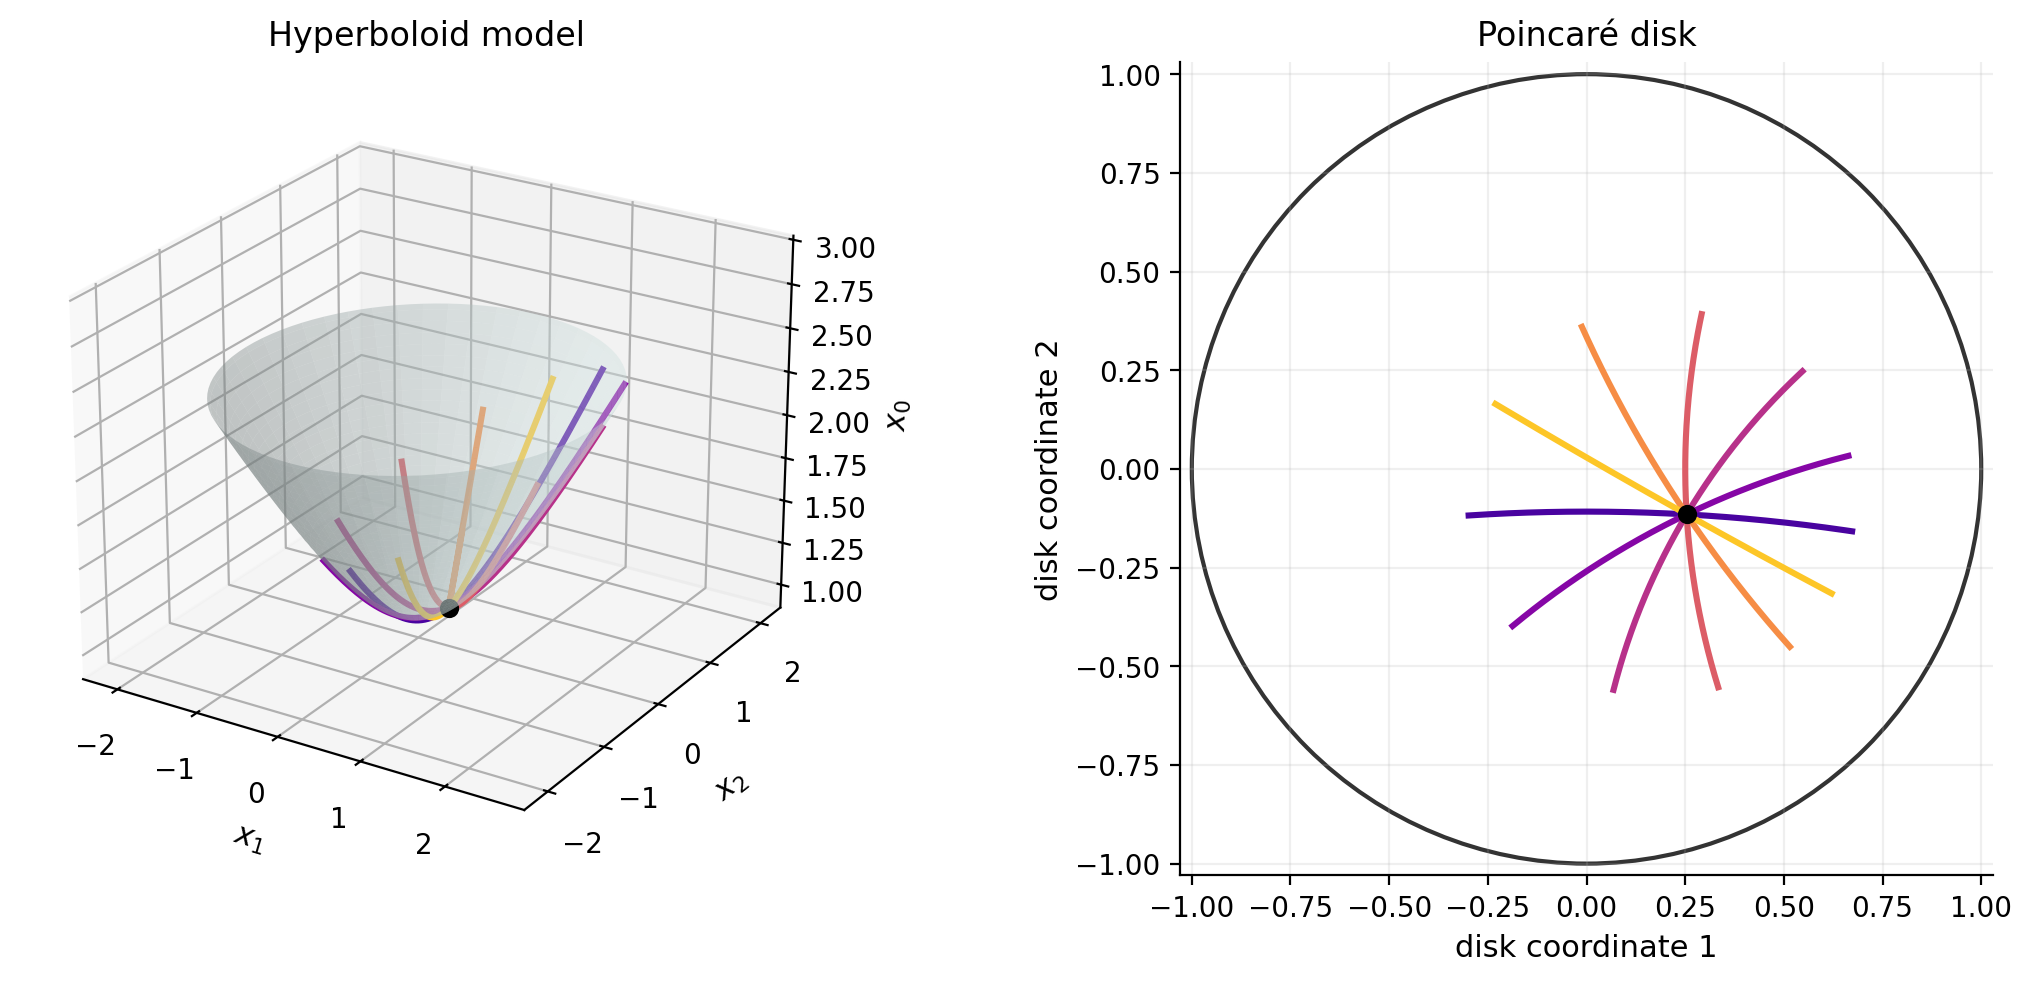

In [4]:
def poincare(point):
    return point[..., 1:] / (point[..., :1] + 1.0)


fig = plt.figure(figsize=(11.5, 4.8), constrained_layout=True)
ax_surface = fig.add_subplot(1, 2, 1, projection="3d")
ax_disk = fig.add_subplot(1, 2, 2)

radii = np.linspace(0.0, 2.1, 70)
azimuths = np.linspace(0.0, 2.0 * np.pi, 100)
R, Phi = np.meshgrid(radii, azimuths)
X1 = R * np.cos(Phi)
X2 = R * np.sin(Phi)
X0 = np.sqrt(1.0 + R**2)
ax_surface.plot_surface(
    X1, X2, X0, color="#D9ECEB", alpha=0.42, linewidth=0, antialiased=True
)

colors = plt.cm.plasma(np.linspace(0.12, 0.88, len(paths)))
for path, color in zip(np.asarray(paths), colors):
    ax_surface.plot(path[:, 1], path[:, 2], path[:, 0], color=color, linewidth=2.2)
    disk_path = np.asarray(poincare(path))
    ax_disk.plot(disk_path[:, 0], disk_path[:, 1], color=color, linewidth=2.2)

base_np = np.asarray(base)
ax_surface.scatter(base_np[1], base_np[2], base_np[0], color="black", s=35, zorder=5)
disk_base = np.asarray(poincare(base))
ax_disk.scatter(disk_base[0], disk_base[1], color="black", s=35, zorder=5)

ax_surface.set(
    title="Hyperboloid model",
    xlabel="$x_1$",
    ylabel="$x_2$",
    zlabel="$x_0$",
)
ax_surface.view_init(elev=24, azim=-58)
ax_surface.set_box_aspect((1, 1, 0.8))

boundary = plt.Circle((0.0, 0.0), 1.0, fill=False, color="0.2", linewidth=1.5)
ax_disk.add_patch(boundary)
ax_disk.set(
    title="Poincaré disk",
    xlabel="disk coordinate 1",
    ylabel="disk coordinate 2",
    xlim=(-1.03, 1.03),
    ylim=(-1.03, 1.03),
)
ax_disk.set_aspect("equal")
ax_disk.grid(alpha=0.2)

plt.show()

The curves are the same geodesics in two coordinate models. The hyperboloid
view makes the ambient Lorentzian construction explicit; the disk gives a
compact picture that is often easier to interpret.

## What to try next

- Move the base point and check that projected geodesics remain inside the disk.
- Verify `H.log(x, H.exp(x, u))` for a small tangent vector `u`.
- Optimize a loss over hyperbolic embeddings using the same `Minimize` API.

The paired-model visualization is inspired by the geometric examples in the
[Geomstats documentation](https://geomstats.github.io/getting_started/examples.html).